<a href="https://colab.research.google.com/github/Codemioo/bioinformatic/blob/main/Sequence_Alignment_%26_Homology_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

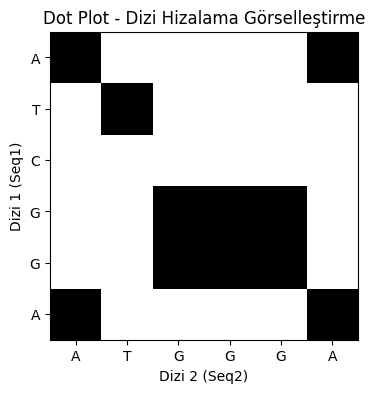

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def create_dot_plot(seq1: str, seq2: str):
    """İki dizi arasındaki eşleşmeleri matris üzerinde görselleştirir."""
    matrix = np.zeros((len(seq1), len(seq2)))

    for i, base1 in enumerate(seq1):
        for j, base2 in enumerate(seq2):
            if base1 == base2:
                matrix[i, j] = 1

    plt.figure(figsize=(4, 4))
    plt.imshow(matrix, cmap='binary', interpolation='nearest')

    # Eksen etiketleri
    plt.xticks(range(len(seq2)), list(seq2))
    plt.yticks(range(len(seq1)), list(seq1))

    plt.xlabel("Dizi 2 (Seq2)")
    plt.ylabel("Dizi 1 (Seq1)")
    plt.title("Dot Plot - Dizi Hizalama Görselleştirme")
    plt.grid(False)
    plt.show()

# --- TEST (Değişken isimleri seq1 ve seq2 olarak eşitlendi) ---
seq1 = "ATCGGA"
seq2 = "ATGGGA"

# Atama doğrudan aynı isimli değişkenlerle yapılıyor
create_dot_plot(seq1, seq2)

In [9]:
import numpy as np

def needleman_wunsch(seq1: str, seq2: str, match=1, mismatch=-1, gap=-1):
    n, m = len(seq1), len(seq2)

    # 1. Matris İlklendirme
    score_matrix = np.zeros((n + 1, m + 1), dtype=int)

    for i in range(1, n + 1):
        score_matrix[i][0] = i * gap
    for j in range(1, m + 1):
        score_matrix[0][j] = j * gap

    # 2. Matris Doldurma
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if seq1[i-1] == seq2[j-1]:
                diag_score = score_matrix[i-1][j-1] + match
            else:
                diag_score = score_matrix[i-1][j-1] + mismatch

            up_score = score_matrix[i-1][j] + gap
            left_score = score_matrix[i][j-1] + gap

            score_matrix[i][j] = max(diag_score, up_score, left_score)

    # 3. Traceback (Geri İzleme)
    align1, align2 = "", ""
    i, j = n, m

    while i > 0 and j > 0:
        current = score_matrix[i][j]
        diag = score_matrix[i-1][j-1]
        up = score_matrix[i-1][j]
        left = score_matrix[i][j-1]

        score = match if seq1[i-1] == seq2[j-1] else mismatch

        if current == diag + score:
            align1 = seq1[i-1] + align1
            align2 = seq2[j-1] + align2
            i -= 1
            j -= 1
        elif current == up + gap:
            align1 = seq1[i-1] + align1
            align2 = "-" + align2
            i -= 1
        else:
            align1 = "-" + align1
            align2 = seq2[j-1] + align2
            j -= 1

    while i > 0:
        align1 = seq1[i-1] + align1
        align2 = "-" + align2
        i -= 1
    while j > 0:
        align1 = "-" + align1
        align2 = seq2[j-1] + align2
        j -= 1

    return align1, align2, score_matrix[n][m], score_matrix

# --- TEST ---
seq1 = "ATGCGA"
seq2 = "ATGGGA"

a1, a2, final_score, matrix = needleman_wunsch(seq1, seq2, match=2, mismatch=-1, gap=-2)

print(f"Hizalanmış Dizi 1: {a1}")
print(f"Hizalanmış Dizi 2: {a2}")
print(f"Hizalama Skoru  : {final_score}")

Hizalanmış Dizi 1: ATGCGA
Hizalanmış Dizi 2: ATGGGA
Hizalama Skoru  : 9


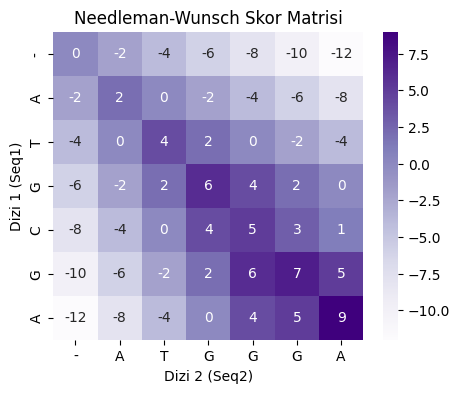

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_alignment_matrix(score_matrix, seq1, seq2):

    plt.figure(figsize=(5, 4))

    # Eksen etiketleri için boşluk (gap) karakterini başa ekliyoruz
    x_labels = ['-'] + list(seq2)
    y_labels = ['-'] + list(seq1)

    sns.heatmap(
        score_matrix,
        annot=True,
        fmt="d",
        cmap="Purples",
        xticklabels=x_labels,
        yticklabels=y_labels,
        cbar=True
    )
    py, px = zip(*path)
    plt.plot([x + 0.5 for x in px], [y + 0.5 for y in py],
             color='blue', linewidth=3, marker='o', markersize=6,
             label='Geri İzleme Yolu')
    plt.xlabel("Dizi 2 (Seq2)")
    plt.ylabel("Dizi 1 (Seq1)")
    plt.title("Needleman-Wunsch Skor Matrisi")
    plt.show()

# Isı haritasını tetikleme
plot_alignment_matrix(matrix, seq1, seq2)

/tmp/ipykernel_5803/1543597371.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


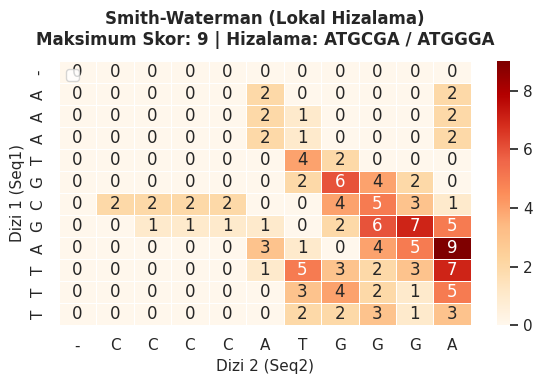

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SMITH-WATERMAN ALGORİTMASI ---
def smith_waterman(seq1: str, seq2: str, match=2, mismatch=-1, gap=-2):
    n, m = len(seq1), len(seq2)
    score_matrix = np.zeros((n + 1, m + 1), dtype=int)
    max_score = 0
    max_pos = (0, 0)

    # Matris Doldurma (Negatif skorlara izin verilmez, min 0)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if seq1[i-1] == seq2[j-1]:
                diag = score_matrix[i-1][j-1] + match
            else:
                diag = score_matrix[i-1][j-1] + mismatch
            up = score_matrix[i-1][j] + gap
            left = score_matrix[i][j-1] + gap

            cell = max(0, diag, up, left)
            score_matrix[i][j] = cell

            if cell > max_score:
                max_score = cell
                max_pos = (i, j)

    # Geri İzleme (Traceback: En yüksek skordan 0'a kadar)
    align1, align2 = "", ""
    i, j = max_pos
    path = [(i, j)]

    while i > 0 and j > 0 and score_matrix[i][j] > 0:
        score = match if seq1[i-1] == seq2[j-1] else mismatch
        if score_matrix[i][j] == score_matrix[i-1][j-1] + score:
            align1 = seq1[i-1] + align1
            align2 = seq2[j-1] + align2
            i -= 1; j -= 1
        elif score_matrix[i][j] == score_matrix[i-1][j] + gap:
            align1 = seq1[i-1] + align1
            align2 = "-" + align2
            i -= 1
        else:
            align1 = "-" + align1
            align2 = seq2[j-1] + align2
            j -= 1
        path.append((i, j))

    return align1, align2, max_score, score_matrix, path


def plot_smith_waterman(seq1: str, seq2: str, match=2, mismatch=-1, gap=-2):
    align1, align2, max_score, matrix, path = smith_waterman(seq1, seq2, match, mismatch, gap)

    sns.set_theme(style="white")
    plt.figure(figsize=(6, 4))

    # Heatmap
    ax = sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="OrRd",
        xticklabels=['-'] + list(seq2),
        yticklabels=['-'] + list(seq1),
        cbar=True,
        linewidths=.5
    )


    plt.title(f"Smith-Waterman (Lokal Hizalama)\nMaksimum Skor: {max_score} | Hizalama: {align1} / {align2}",
              fontsize=12, fontweight='bold', pad=12)
    plt.xlabel("Dizi 2 (Seq2)", fontsize=11)
    plt.ylabel("Dizi 1 (Seq1)", fontsize=11)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# --- TEST ---
seq1 = "AAATGCGATTT"
seq2 = "CCCCATGGGA"

plot_smith_waterman(seq1, seq2, match=2, mismatch=-1, gap=-2)

Needleman-Wunsch, dizileri baştan sona (global) hizalamaya zorlar; bu nedenle uçlardaki uyuşmazlıklar veya uzantılar skoru düşürür.Smith-Waterman ise matriste negatif değerlere izin vermeyerek ($0$ ile sınırlandırarak) diziler içindeki en korunan/benzer bölgeyi (lokal) bulur. Korunmamış dizilimlerin yarattığı gürültüyü eler.